In [1]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
import splitfolders
import matplotlib.pyplot as plt
import os
import shutil

print(f"Versi TensorFlow: {tf.__version__}")

dataset_url = "https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz"
data_dir = tf.keras.utils.get_file('flower_photos', origin=dataset_url, untar=True)

base_dir = 'flower_dataset'
if os.path.exists(base_dir):
    shutil.rmtree(base_dir)

splitfolders.ratio(data_dir, output=base_dir, seed=42, ratio=(.8, .1, .1))

train_dir = os.path.join(base_dir, 'train')
val_dir = os.path.join(base_dir, 'val')
test_dir = os.path.join(base_dir, 'test')
print("Dataset siap!")

Versi TensorFlow: 2.10.0
Dataset siap!


In [2]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    horizontal_flip=True,
    shear_range=0.2,
    fill_mode='nearest'
)
test_val_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    train_dir, target_size=(150, 150), batch_size=32, class_mode='categorical'
)
val_gen = test_val_datagen.flow_from_directory(
    val_dir, target_size=(150, 150), batch_size=32, class_mode='categorical'
)
test_gen = test_val_datagen.flow_from_directory(
    test_dir, target_size=(150, 150), batch_size=32, class_mode='categorical', shuffle=False
)

Found 2934 images belonging to 5 classes.
Found 364 images belonging to 5 classes.
Found 372 images belonging to 5 classes.


In [3]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(150, 150, 3), include_top=False, weights='imagenet'
)
base_model.trainable = False 

model = Sequential([
    base_model,
    Conv2D(64, (3,3), activation='relu', padding='same'),
    MaxPooling2D(2,2),                                    
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5), 
    Dense(5, activation='softmax') 
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=3, restore_best_weights=True)
]

print("=== MEMULAI TRAINING ===")
history = model.fit(train_gen, epochs=10, validation_data=val_gen, callbacks=callbacks)

=== MEMULAI TRAINING ===
Epoch 1/10
92/92 [==============================] - 113s 1s/step - loss: 1.1227 - accuracy: 0.6350 - val_loss: 0.5300 - val_accuracy: 0.8269
Epoch 2/10
92/92 [==============================] - 28s 300ms/step - loss: 0.5595 - accuracy: 0.8047 - val_loss: 0.4919 - val_accuracy: 0.8379
Epoch 3/10
92/92 [==============================] - 28s 298ms/step - loss: 0.4522 - accuracy: 0.8401 - val_loss: 0.4787 - val_accuracy: 0.8324
Epoch 4/10
92/92 [==============================] - 61s 665ms/step - loss: 0.3582 - accuracy: 0.8773 - val_loss: 0.4511 - val_accuracy: 0.8516
Epoch 5/10
92/92 [==============================] - 62s 674ms/step - loss: 0.3317 - accuracy: 0.8824 - val_loss: 0.5896 - val_accuracy: 0.8544
Epoch 6/10
92/92 [==============================] - 36s 381ms/step - loss: 0.2726 - accuracy: 0.8998 - val_loss: 0.5897 - val_accuracy: 0.8242
Epoch 7/10
92/92 [==============================] - 29s 309ms/step - loss: 0.2336 - accuracy: 0.9114 - val_loss: 0.6594

12/12 [==============================] - 11s 936ms/step - loss: 0.4738 - accuracy: 0.8710

---> Akurasi Testing: 87.10% <---


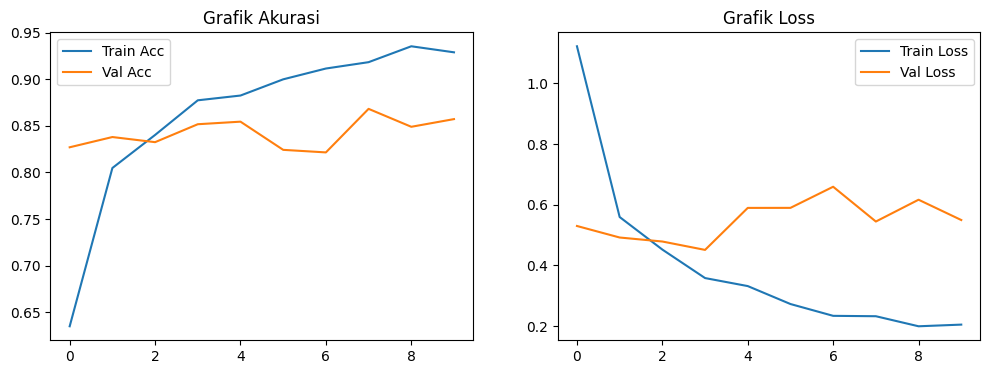

In [4]:
test_loss, test_acc = model.evaluate(test_gen)
print(f"\n---> Akurasi Testing: {test_acc * 100:.2f}% <---")

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Grafik Akurasi')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Grafik Loss')
plt.legend()
plt.show()

In [5]:
import os
import tensorflow as tf

os.makedirs('submission/saved_model', exist_ok=True)
os.makedirs('submission/tflite', exist_ok=True)
os.makedirs('submission/tfjs_model', exist_ok=True)

model.save('submission/saved_model')
print("Model berhasil disimpan ke format SavedModel!")

converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()
with open('submission/tflite/model.tflite', 'wb') as f:
    f.write(tflite_model)
    
labels = '\n'.join(sorted(train_gen.class_indices.keys()))
with open('submission/tflite/label.txt', 'w') as f:
    f.write(labels)
print("Model berhasil disimpan ke format TF-Lite!")

!pip install tensorflowjs -q
import tensorflowjs as tfjs
tfjs.converters.save_keras_model(model, 'submission/tfjs_model')
print("Model berhasil dikonversi dan disimpan ke format TFJS!")

INFO:tensorflow:Assets written to: submission/saved_model\assets


INFO:tensorflow:Assets written to: submission/saved_model\assets


Model berhasil disimpan ke format SavedModel!


INFO:tensorflow:Assets written to: C:\Users\atha\AppData\Local\Temp\tmp3tgyekxl\assets


INFO:tensorflow:Assets written to: C:\Users\atha\AppData\Local\Temp\tmp3tgyekxl\assets


Model berhasil disimpan ke format TF-Lite!


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ipykernel 7.3.0 requires packaging>=22, but you have packaging 20.9 which is incompatible.


Model berhasil dikonversi dan disimpan ke format TFJS!



Evaluasi pada Testing Set: 
12/12 [==============================] - 3s 238ms/step - loss: 0.4738 - accuracy: 0.8710
Akurasi Testing: 87.10%


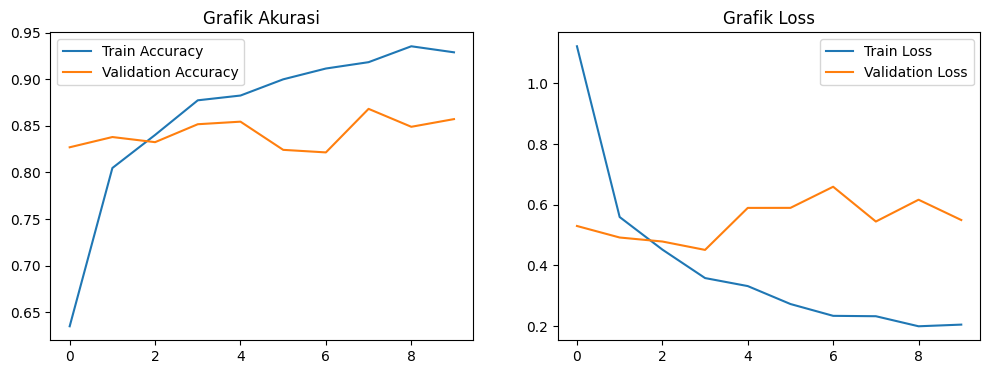

In [6]:
print("\nEvaluasi pada Testing Set: ")
test_loss, test_acc = model.evaluate(test_gen)
print(f"Akurasi Testing: {test_acc * 100:.2f}%")

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Grafik Akurasi')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Grafik Loss')
plt.legend()
plt.show()

In [7]:
import os
os.makedirs('submission/saved_model', exist_ok=True)
os.makedirs('submission/tflite', exist_ok=True)
os.makedirs('submission/tfjs_model', exist_ok=True)

model.save('submission/saved_model')
print("Model berhasil disimpan ke format SavedModel!")

converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()
with open('submission/tflite/model.tflite', 'wb') as f:
    f.write(tflite_model)

labels = '\n'.join(sorted(train_gen.class_indices.keys()))
with open('submission/tflite/label.txt', 'w') as f:
    f.write(labels)
print("Model berhasil disimpan ke format TF-Lite!")

INFO:tensorflow:Assets written to: submission/saved_model\assets


INFO:tensorflow:Assets written to: submission/saved_model\assets


Model berhasil disimpan ke format SavedModel!


INFO:tensorflow:Assets written to: C:\Users\atha\AppData\Local\Temp\tmp5vmf88as\assets


INFO:tensorflow:Assets written to: C:\Users\atha\AppData\Local\Temp\tmp5vmf88as\assets


Model berhasil disimpan ke format TF-Lite!
